In [1]:
# 노트북 안에서 설치가 필요한 경우에만 아래 명령어의 주석을 해제하고 실행합니다.
# 단, 현재 선택된 Jupyter 커널이 uv 가상환경인지 먼저 확인해야 합니다.
#!pip install pandas numpy matplotlib seaborn folium ipywidgets scikit-learn

In [2]:
%matplotlib inline

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# seaborn: heatmap, barplot처럼 보기 좋은 그래프를 그릴 때 사용합니다.
import seaborn as sns

# folium: 위도/경도 데이터를 지도 위에 표시할 때 사용합니다.
import folium

# HeatMap: folium 지도 위에 데이터 밀집 정도를 색으로 표현하는 도구입니다.
from folium.plugins import HeatMap

In [3]:
plt.style.use('ggplot')

In [4]:
# 한글 폴트 설정 (Windows 기준). 폰트가 없거나 다른 OS에서 실행해도 오류가 나지 않도록 예외 처리합니다.
try:
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['axes.unicode_minus'] = False
except Exception as e:
    print('한글 폰트 설정을 건너뜁니다:', e)

In [5]:
df = pd.read_csv('jeju_bus.csv')
df

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210452,210452,2019-10-28,405328102,7983486,281-2,33.255783,126.577450,비석거리,21시,528.0,삼아아파트,33.251896,126.574417,96
210453,210453,2019-10-28,405328102,7983486,281-2,33.248595,126.568527,동문로터리,21시,280.0,매일올레시장 7번입구,33.249753,126.565959,50
210454,210454,2019-10-28,405328102,7983486,281-2,33.251891,126.560303,서귀포시 구 버스터미널,21시,114.0,아랑조을거리 입구,33.251084,126.559551,16
210455,210455,2019-10-28,405328102,7983486,281-2,33.251084,126.559551,아랑조을거리 입구,21시,223.0,평생학습관,33.249504,126.558068,38


In [6]:
df

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210452,210452,2019-10-28,405328102,7983486,281-2,33.255783,126.577450,비석거리,21시,528.0,삼아아파트,33.251896,126.574417,96
210453,210453,2019-10-28,405328102,7983486,281-2,33.248595,126.568527,동문로터리,21시,280.0,매일올레시장 7번입구,33.249753,126.565959,50
210454,210454,2019-10-28,405328102,7983486,281-2,33.251891,126.560303,서귀포시 구 버스터미널,21시,114.0,아랑조을거리 입구,33.251084,126.559551,16
210455,210455,2019-10-28,405328102,7983486,281-2,33.251084,126.559551,아랑조을거리 입구,21시,223.0,평생학습관,33.249504,126.558068,38


In [7]:
df['now_arrive_time'].str.replace('시', '', regex=False)

0         06
1         06
2         06
3         06
4         07
          ..
210452    21
210453    21
210454    21
210455    21
210456    21
Name: now_arrive_time, Length: 210457, dtype: str

In [8]:
# regex: 정규식 여부 확인
df['now_hour'] = df['now_arrive_time'].str.replace('시', '', regex=False).astype(int)

In [9]:
df[ ['now_arrive_time', 'now_hour'] ]

,now_arrive_time,now_hour
0,06시,6
1,06시,6
2,06시,6
3,06시,6
4,07시,7
...,...,...
210452,21시,21
210453,21시,21
210454,21시,21
210455,21시,21


In [10]:
df['date'] = pd.to_datetime( df['date'] )

In [11]:
df['dayofweek'] = df['date'].dt.dayofweek

In [12]:
df

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time,now_hour,dayofweek
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24,6,1
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36,6,1
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40,6,1
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42,6,1
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210452,210452,2019-10-28,405328102,7983486,281-2,33.255783,126.577450,비석거리,21시,528.0,삼아아파트,33.251896,126.574417,96,21,0
210453,210453,2019-10-28,405328102,7983486,281-2,33.248595,126.568527,동문로터리,21시,280.0,매일올레시장 7번입구,33.249753,126.565959,50,21,0
210454,210454,2019-10-28,405328102,7983486,281-2,33.251891,126.560303,서귀포시 구 버스터미널,21시,114.0,아랑조을거리 입구,33.251084,126.559551,16,21,0
210455,210455,2019-10-28,405328102,7983486,281-2,33.251084,126.559551,아랑조을거리 입구,21시,223.0,평생학습관,33.249504,126.558068,38,21,0


In [13]:
plt.style.use('ggplot')

(array([2.8159e+04, 7.5575e+04, 4.6484e+04, 2.3597e+04, 1.5965e+04,
        9.0000e+03, 4.4200e+03, 1.9500e+03, 1.2480e+03, 1.1390e+03,
        7.3700e+02, 3.0000e+02, 1.7000e+02, 2.6900e+02, 1.9100e+02,
        1.0700e+02, 9.5000e+01, 2.2000e+02, 2.3400e+02, 1.6300e+02,
        6.7000e+01, 2.9000e+01, 2.4000e+01, 1.5000e+01, 1.8000e+01,
        1.9000e+01, 8.0000e+00, 1.1000e+01, 1.2000e+01, 5.0000e+00,
        1.5000e+01, 4.0000e+00, 5.0000e+00, 1.0000e+01, 5.0000e+00,
        7.0000e+00, 6.0000e+00, 8.0000e+00, 1.0000e+01, 3.0000e+00,
        3.0000e+00, 7.0000e+00, 2.0000e+00, 4.0000e+00, 5.0000e+00,
        4.0000e+00, 3.0000e+00, 3.0000e+00, 3.0000e+00, 3.0000e+00,
        7.0000e+00, 2.0000e+00, 5.0000e+00, 1.0000e+00, 3.0000e+00,
        3.0000e+00, 2.0000e+00, 2.0000e+00, 4.0000e+00, 5.0000e+00,
        3.0000e+00, 2.0000e+00, 3.0000e+00, 1.0000e+00, 3.0000e+00,
        1.0000e+00, 1.0000e+00, 3.0000e+00, 2.0000e+00, 1.0000e+00,
        3.0000e+00, 2.0000e+00, 7.0000e+00, 1.00

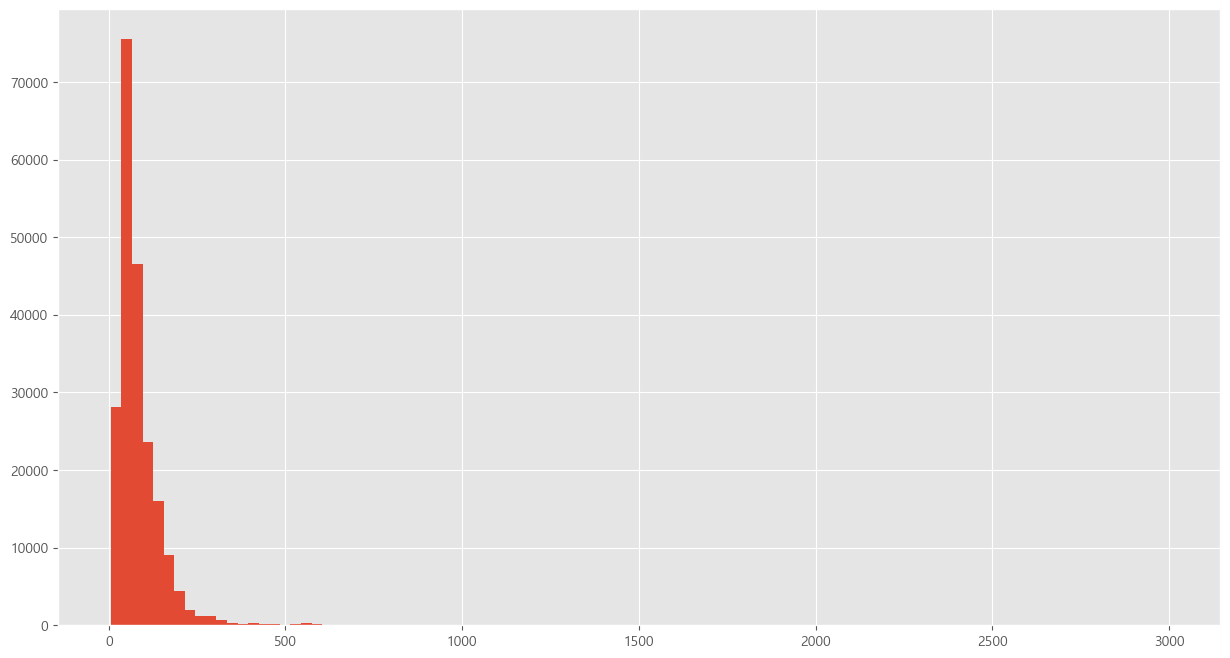

In [14]:
plt.figure(figsize=(15, 8) )
plt.hist( df['next_arrive_time'], bins = 100 )

{'whiskers': [<matplotlib.lines.Line2D at 0x18de61156d0>,
 'caps': [<matplotlib.lines.Line2D at 0x18de6114450>,
 'boxes': [<matplotlib.lines.Line2D at 0x18de31be610>],
 'medians': [<matplotlib.lines.Line2D at 0x18de6103050>],
 'fliers': [<matplotlib.lines.Line2D at 0x18de6102750>],
 'means': []}

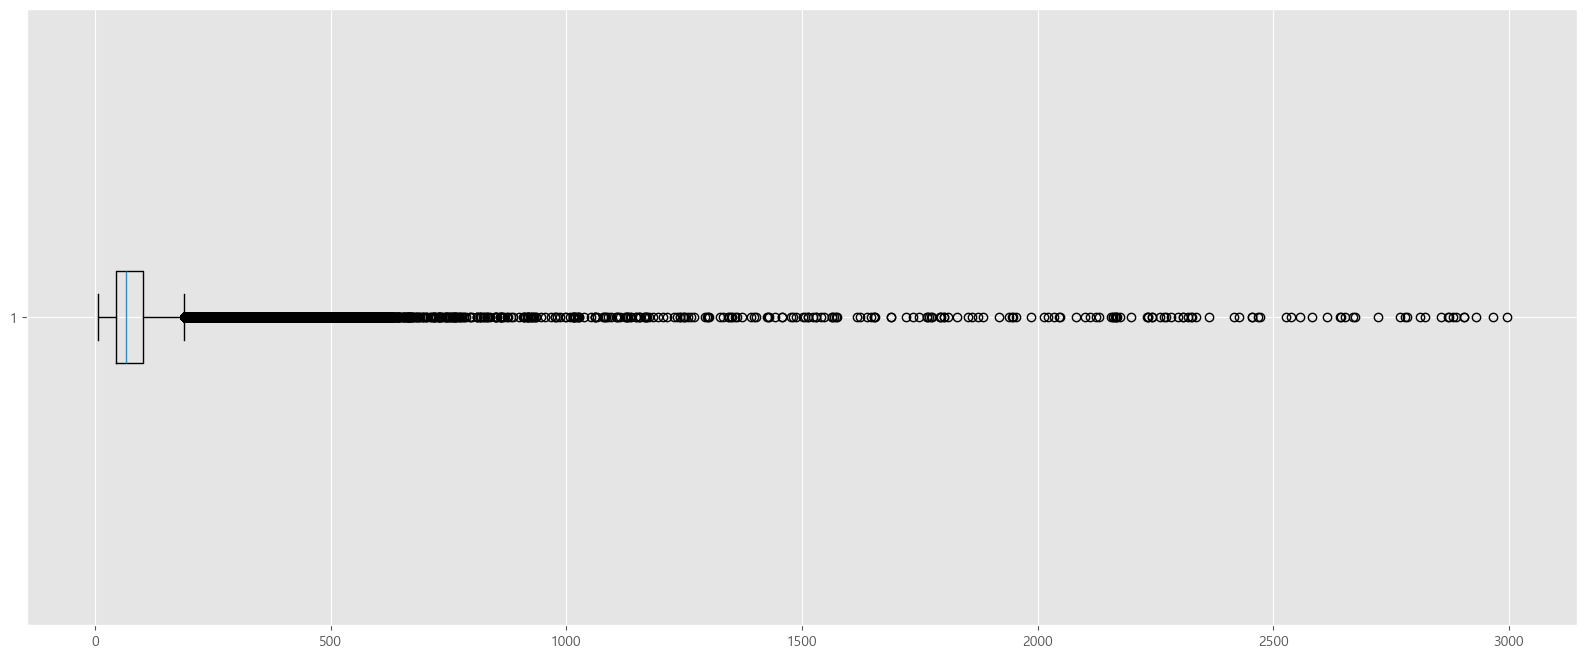

In [15]:
plt.figure(figsize = (20, 8))
# vert: 수직 수평 여부
plt.boxplot( df['next_arrive_time'], vert=False )

In [16]:
Q1 = df['next_arrive_time'].quantile(0.25)

Q1

np.float64(44.0)

In [17]:
Q2 = df['next_arrive_time'].quantile(0.5)
Q2

np.float64(66.0)

In [18]:
Q3 = df['next_arrive_time'].quantile(0.75)
Q3

np.float64(102.0)

In [19]:
IQR = Q3 - Q1
IQR

np.float64(58.0)

In [20]:
Q1 - 1.5 * IQR

np.float64(-43.0)

In [21]:
Q3 + 1.5 * IQR

np.float64(189.0)

In [22]:
# 이상치 확인
q90 = df['next_arrive_time'].quantile(0.90)

q90

np.float64(154.0)

In [23]:
df_under_q90 = df[ df['next_arrive_time'] <= q90 ]

In [24]:
df_under_q90

,id,date,route_id,vh_id,route_nm,now_latitude,now_longitude,now_station,now_arrive_time,distance,next_station,next_latitude,next_longitude,next_arrive_time,now_hour,dayofweek
0,0,2019-10-15,405136001,7997025,360-1,33.456267,126.551750,제주대학교입구,06시,266.0,제대마을,33.457724,126.554014,24,6,1
1,1,2019-10-15,405136001,7997025,360-1,33.457724,126.554014,제대마을,06시,333.0,제대아파트,33.458783,126.557353,36,6,1
2,2,2019-10-15,405136001,7997025,360-1,33.458783,126.557353,제대아파트,06시,415.0,제주대학교,33.459893,126.561624,40,6,1
3,3,2019-10-15,405136001,7997025,360-1,33.479705,126.543811,남국원(아라방면),06시,578.0,제주여자중고등학교(아라방면),33.484860,126.542928,42,6,1
4,4,2019-10-15,405136001,7997025,360-1,33.485662,126.494923,도호동,07시,374.0,은남동,33.485822,126.490897,64,7,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
210452,210452,2019-10-28,405328102,7983486,281-2,33.255783,126.577450,비석거리,21시,528.0,삼아아파트,33.251896,126.574417,96,21,0
210453,210453,2019-10-28,405328102,7983486,281-2,33.248595,126.568527,동문로터리,21시,280.0,매일올레시장 7번입구,33.249753,126.565959,50,21,0
210454,210454,2019-10-28,405328102,7983486,281-2,33.251891,126.560303,서귀포시 구 버스터미널,21시,114.0,아랑조을거리 입구,33.251084,126.559551,16,21,0
210455,210455,2019-10-28,405328102,7983486,281-2,33.251084,126.559551,아랑조을거리 입구,21시,223.0,평생학습관,33.249504,126.558068,38,21,0


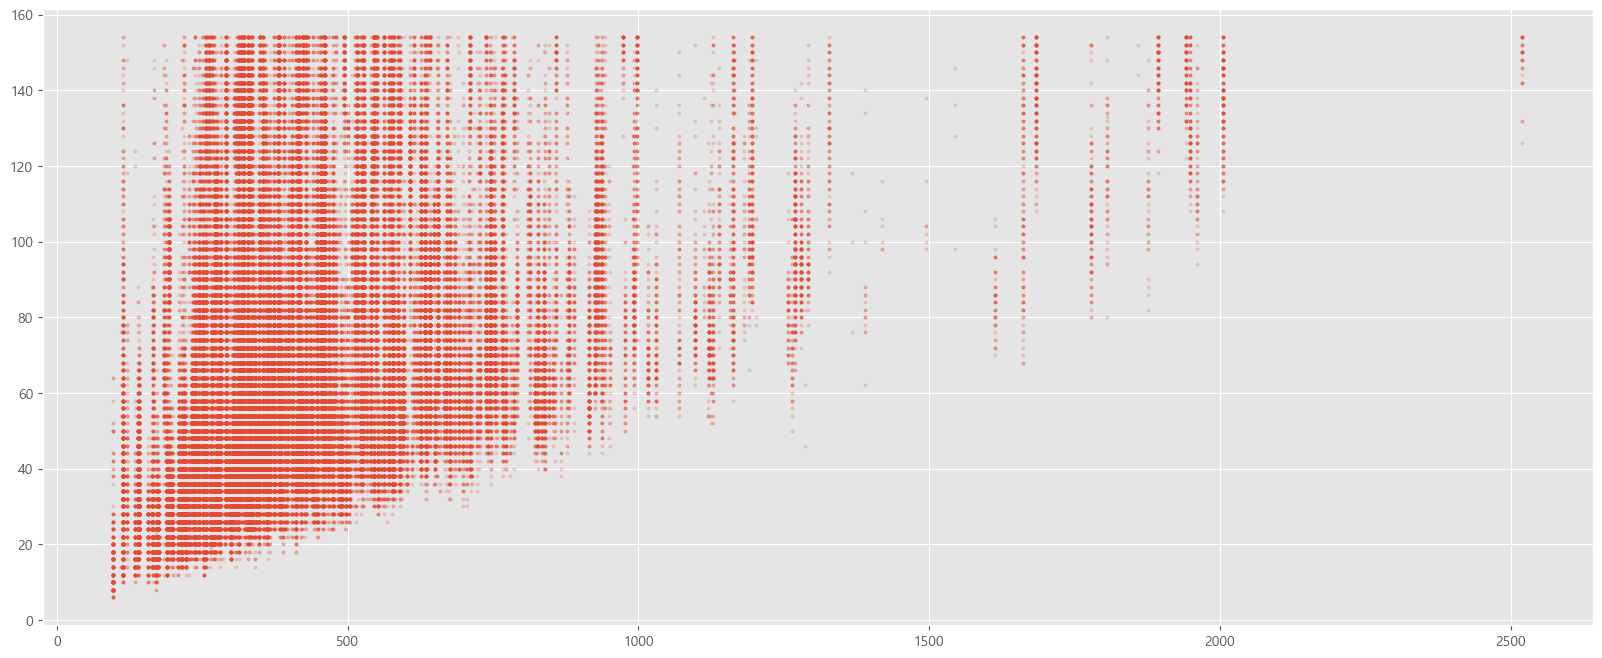

In [25]:
plt.figure(figsize=(20,8))

# s: 원 크기
# alpha: 투명도
plt.scatter(
    x = df_under_q90['distance'],
    y = df_under_q90['next_arrive_time'],
    s = 5,
    alpha = 0.2
    )